In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
import io

putanja = "data/upsell_diplomski.xlsx"

sirovo = pd.read_excel(putanja)
tekst = sirovo.columns[0] + "\n" + "\n".join(sirovo.iloc[:, 0].astype(str))
df = pd.read_csv(io.StringIO(tekst))

print("Dimenzije baze:", df.shape)

Dimenzije baze: (592839, 50)


In [3]:

user_ids = df['user_id']          # sacuvaj identifikatore pre izbacivanja

df.drop(columns=['user_id', 'tariff_number_after_renewal', 'Steel_phone'], inplace=True, errors='ignore')

df = df.dropna()

print("Novi oblik tabele:", df.shape)
df.info()

<class 'pandas.DataFrame'>
Index: 590759 entries, 0 to 592838
Data columns (total 47 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   upsell                               590759 non-null  int64  
 1   tariff_number_before_renewal         590759 non-null  str    
 2   Adequate_Tariff_Flag                 590759 non-null  int64  
 3   Moj_A1_purchase_trend                590759 non-null  int64  
 4   Elderly_Age_segment                  590759 non-null  int64  
 5   Regular_Traveler_Flag                590759 non-null  int64  
 6   Last_Payment_Channel_BankPayments    590759 non-null  int64  
 7   Moderate_MOU_Flag                    590759 non-null  int64  
 8   No_phone                             590759 non-null  int64  
 9   Very_Heavy_SMS_Flag                  590759 non-null  int64  
 10  Heavy_MOU_Flag                       590759 non-null  int64  
 11  Weekend_Traveler_Flag        

In [4]:


df['tariff_number_before_renewal'] = df['tariff_number_before_renewal'].str.strip('" ')

vazne_tarife = ['Tariff 1', 'Tariff 2', 'Tariff 3', 'Tariff 3a', 'Tariff 3b', 'Tariff 4', 'Tariff 5', 'Tariff 6']
df = df[df['tariff_number_before_renewal'].isin(vazne_tarife)]


df_final = pd.get_dummies(df, columns=['tariff_number_before_renewal'], prefix='T', drop_first=False, dtype=int)

print(df_final.filter(like='T_Tariff').columns.tolist())

display(df_final.head())
print(df_final.columns.tolist())

print("Info o kolonama:")
df_final.info()

print("Statistika:")
display(df_final.describe())

,upsell,Adequate_Tariff_Flag,Moj_A1_purchase_trend,Elderly_Age_segment,Regular_Traveler_Flag,Last_Payment_Channel_BankPayments,Moderate_MOU_Flag,No_phone,Very_Heavy_SMS_Flag,Heavy_MOU_Flag,...,Send_Mail_6_Months,Migration_Flag,T_Tariff 1,T_Tariff 2,T_Tariff 3,T_Tariff 3a,T_Tariff 3b,T_Tariff 4,T_Tariff 5,T_Tariff 6
count,590731.000000,590731.000000,590731.000000,590731.000000,590731.000000,590731.000000,590731.000000,590731.000000,590731.000000,590731.000000,...,590731.000000,590731.000000,590731.000000,590731.000000,590731.000000,590731.000000,590731.000000,590731.00000,590731.000000,590731.000000
mean,0.283034,0.413982,0.040179,0.163142,0.177296,0.337225,0.338704,0.251060,0.130471,0.284070,...,0.295471,0.130667,0.084028,0.210233,0.193059,0.008305,0.091079,0.32606,0.086706,0.000530
std,0.450473,0.492546,0.649945,0.369495,0.381919,0.472763,0.473269,0.433623,0.336821,0.450971,...,0.456255,0.337036,0.277430,0.407474,0.394699,0.090752,0.287721,0.46877,0.281404,0.023012
min,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
75%,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.00000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000


In [5]:

df_final.info()
print(df_final['upsell'].value_counts())

<class 'pandas.DataFrame'>
Index: 590731 entries, 0 to 592838
Data columns (total 54 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   upsell                               590731 non-null  int64  
 1   Adequate_Tariff_Flag                 590731 non-null  int64  
 2   Moj_A1_purchase_trend                590731 non-null  int64  
 3   Elderly_Age_segment                  590731 non-null  int64  
 4   Regular_Traveler_Flag                590731 non-null  int64  
 5   Last_Payment_Channel_BankPayments    590731 non-null  int64  
 6   Moderate_MOU_Flag                    590731 non-null  int64  
 7   No_phone                             590731 non-null  int64  
 8   Very_Heavy_SMS_Flag                  590731 non-null  int64  
 9   Heavy_MOU_Flag                       590731 non-null  int64  
 10  Weekend_Traveler_Flag                590731 non-null  int64  
 11  Headphones_Flag_Last_Contract

In [6]:
df_final.describe()

,upsell,Adequate_Tariff_Flag,Moj_A1_purchase_trend,Elderly_Age_segment,Regular_Traveler_Flag,Last_Payment_Channel_BankPayments,Moderate_MOU_Flag,No_phone,Very_Heavy_SMS_Flag,Heavy_MOU_Flag,...,Send_Mail_6_Months,Migration_Flag,T_Tariff 1,T_Tariff 2,T_Tariff 3,T_Tariff 3a,T_Tariff 3b,T_Tariff 4,T_Tariff 5,T_Tariff 6
count,590731.000000,590731.000000,590731.000000,590731.000000,590731.000000,590731.000000,590731.000000,590731.000000,590731.000000,590731.000000,...,590731.000000,590731.000000,590731.000000,590731.000000,590731.000000,590731.000000,590731.000000,590731.00000,590731.000000,590731.000000
mean,0.283034,0.413982,0.040179,0.163142,0.177296,0.337225,0.338704,0.251060,0.130471,0.284070,...,0.295471,0.130667,0.084028,0.210233,0.193059,0.008305,0.091079,0.32606,0.086706,0.000530
std,0.450473,0.492546,0.649945,0.369495,0.381919,0.472763,0.473269,0.433623,0.336821,0.450971,...,0.456255,0.337036,0.277430,0.407474,0.394699,0.090752,0.287721,0.46877,0.281404,0.023012
min,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
75%,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.00000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000


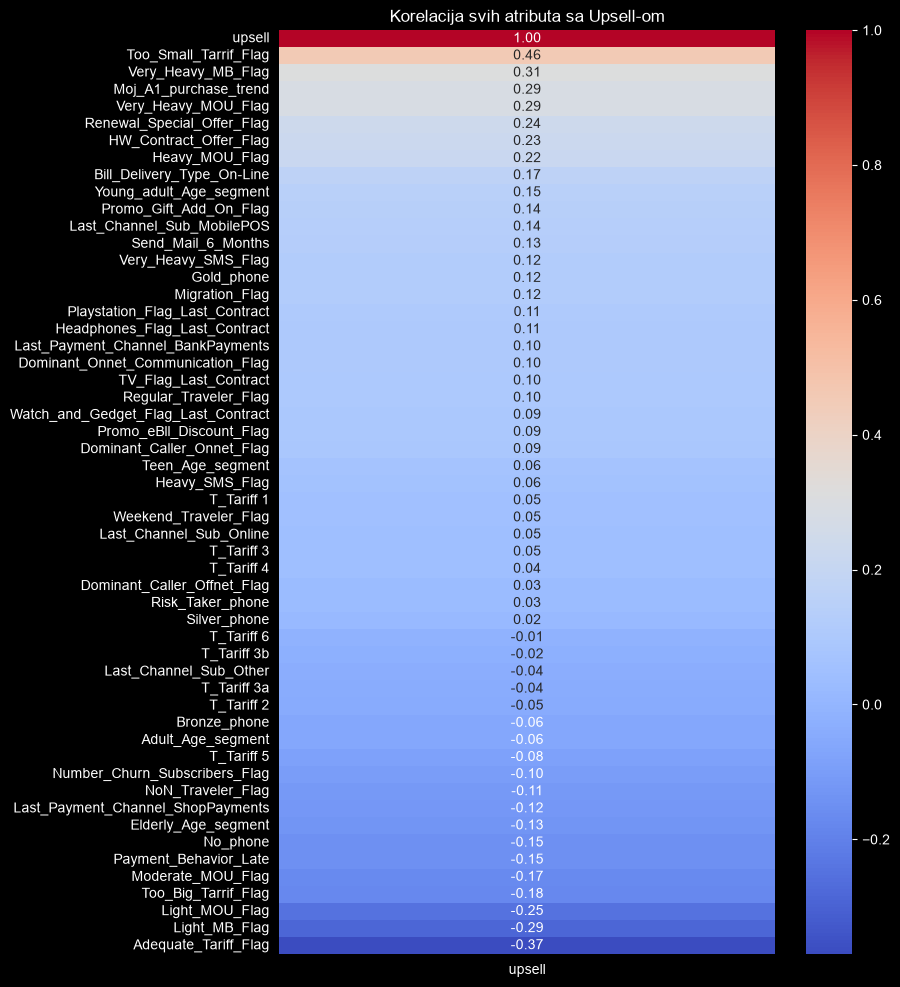

In [7]:
target_corr = df_final.corr()['upsell'].sort_values(ascending=False)

plt.figure(figsize=(8, 12))
sns.heatmap(target_corr.to_frame(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Korelacija svih atributa sa Upsell-om")
plt.show()

In [8]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

X = df_final.drop(columns=['upsell'], errors='ignore')
y = df_final['upsell']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [9]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=7)

param_grid = {
    'max_depth': [3, 4, 5, 6, 8, 10, 12],
    'min_samples_leaf': [50, 200, 1000],
    'criterion': ['gini', 'entropy']
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    param_grid=param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print(f"Najbolji parametri: {grid.best_params_}")
print(f"Najbolji F1 (CV):   {grid.best_score_:.2%}")

tree = grid.best_estimator_

Najbolji parametri: {'criterion': 'entropy', 'max_depth': 12, 'min_samples_leaf': 50}
Najbolji F1 (CV):   74.65%


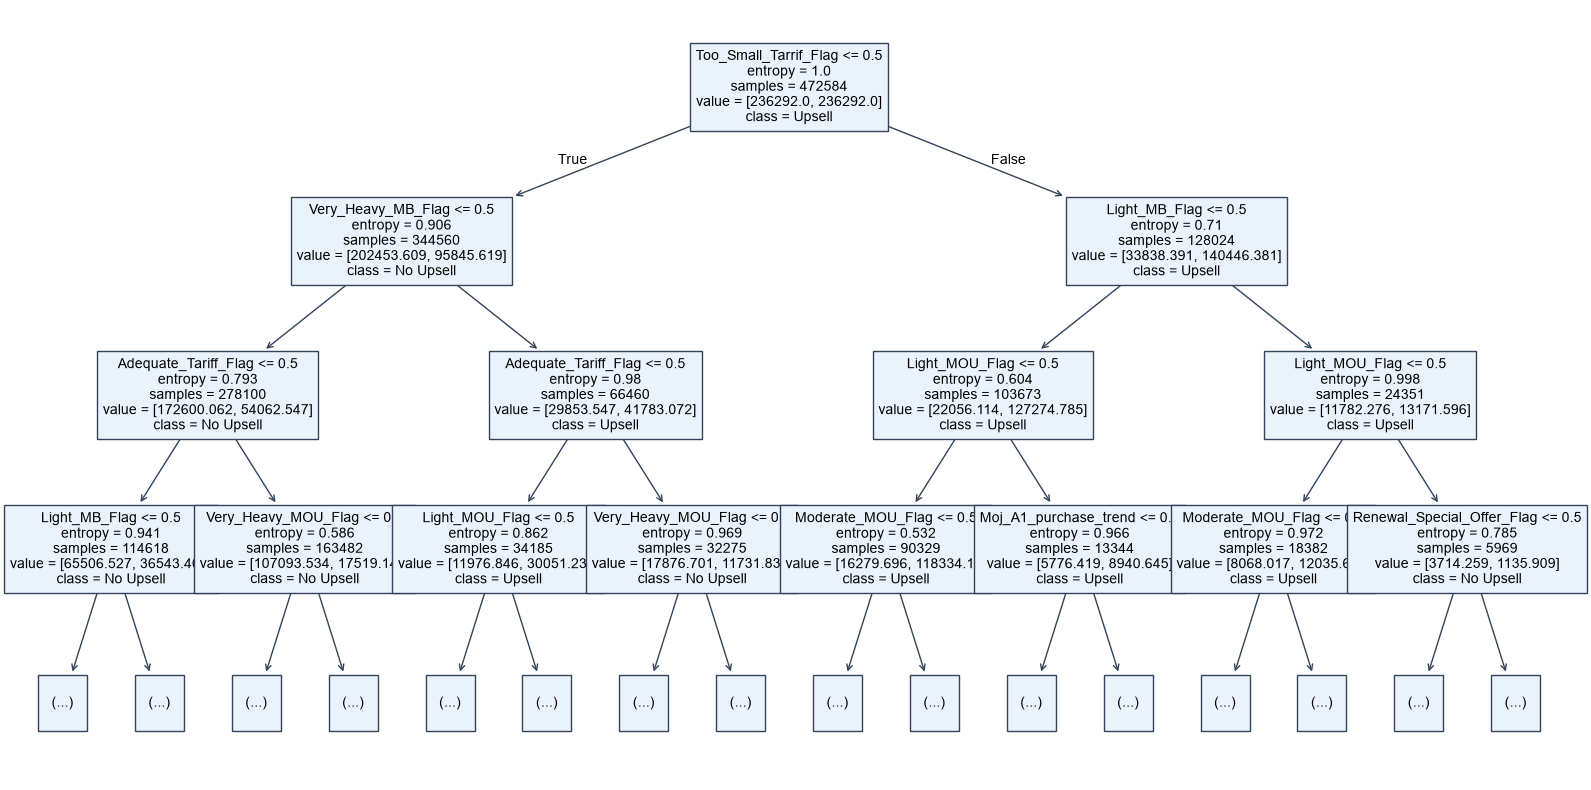

In [10]:
plt.figure(figsize=(20, 10), facecolor='white')
kutije = plot_tree(tree, max_depth=3, feature_names=X.columns,
                   class_names=['No Upsell', 'Upsell'], fontsize=10)
plt.draw()

for k in kutije:
    k.set_color('black')
    if k.get_bbox_patch() is not None:
        k.get_bbox_patch().set_facecolor('#EAF2FB')
        k.get_bbox_patch().set_edgecolor('#33445A')
    if k.arrow_patch is not None:
        k.arrow_patch.set_edgecolor('#33445A')
        k.arrow_patch.set_facecolor('#33445A')

plt.show()

In [11]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
y_pred = tree.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print(f"Precision: {precision_score(y_test, y_pred):.2%}")
recall = recall_score(y_test, y_pred)

print(f"Recall: {recall:.2%}")
print(f"F1: {f1_score(y_test, y_pred):.2%}")

Accuracy: 83.74%
Precision: 66.89%
Recall: 84.23%
F1: 74.57%


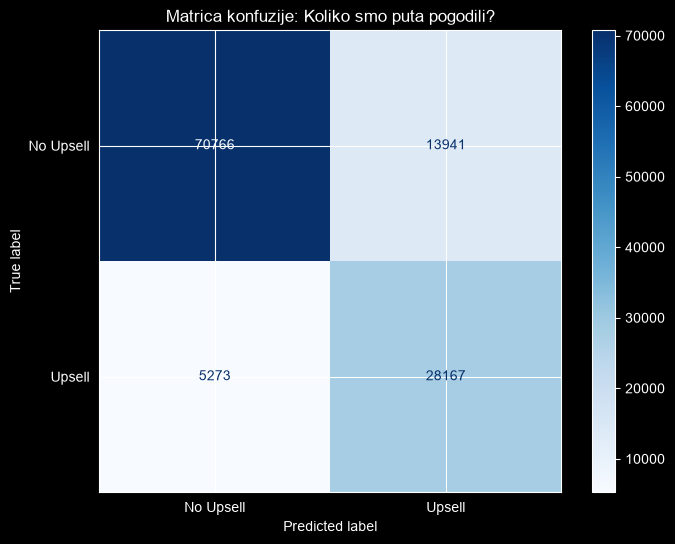

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = tree.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Upsell', 'Upsell'])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title("Matrica konfuzije: Koliko smo puta pogodili?")
plt.show()

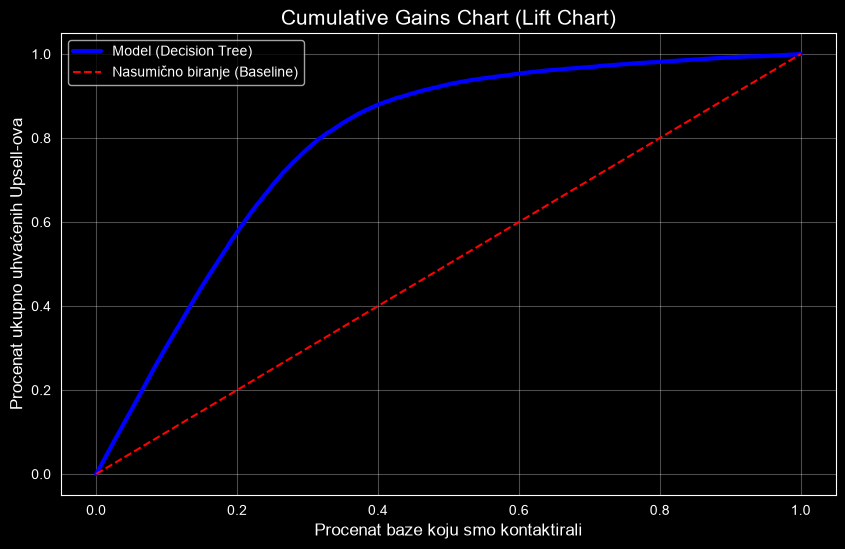

In [13]:
import matplotlib.pyplot as plt
import numpy as np

y_score = tree.predict_proba(X_test)[:, 1]

indices = np.argsort(y_score)[::-1]
y_test_sorted = y_test.values[indices]

cumulative_gains = np.cumsum(y_test_sorted) / np.sum(y_test_sorted)
percentage_of_population = np.arange(1, len(y_test_sorted) + 1) / len(y_test_sorted)

plt.figure(figsize=(10, 6))
plt.plot(percentage_of_population, cumulative_gains, label='Model (Decision Tree)', color='blue', lw=3)
plt.plot([0, 1], [0, 1], 'k--', label='Nasumično biranje (Baseline)',color='red')

plt.title('Cumulative Gains Chart (Lift Chart)', fontsize=15)
plt.xlabel('Procenat baze koju smo kontaktirali', fontsize=12)
plt.ylabel('Procenat ukupno uhvaćenih Upsell-ova', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=7)

param_grid = {
    'max_depth': [8, 12, None],
    'min_samples_leaf': [50, 200]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(n_estimators=100, class_weight='balanced',
                           random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=cv,
    scoring='f1',
    verbose=1
)

grid_rf.fit(X_train, y_train)

print(f"Najbolji parametri: {grid_rf.best_params_}")
print(f"Najbolji F1 (CV):   {grid_rf.best_score_:.2%}")


Najbolji parametri: {'max_depth': None, 'min_samples_leaf': 50}
Najbolji F1 (CV):   77.12%


In [15]:
rf = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                            random_state=42, n_jobs=-1, **grid_rf.best_params_)
rf.fit(X_train, y_train);

In [16]:
from sklearn.metrics import f1_score, roc_auc_score

y_pred_rf = rf.predict(X_test)
y_score_rf = rf.predict_proba(X_test)[:, 1]

print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.2%}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.2%}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.2%}")
print(f"F1:        {f1_score(y_test, y_pred_rf):.2%}")
print(f"AUC:       {roc_auc_score(y_test, y_score_rf):.3f}")

Accuracy:  85.56%
Precision: 70.02%
Recall:    85.65%
F1:        77.05%
AUC:       0.916


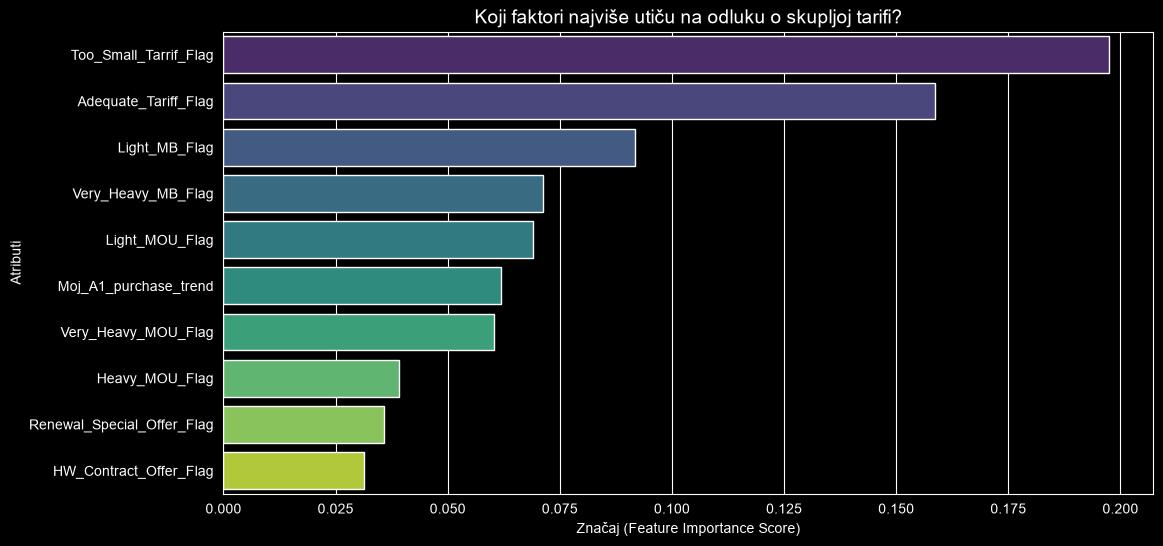

In [17]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
top_10 = importances.sort_values(ascending=False).head(10)

print("KLJUČNI FAKTORI ZA UPSELL (Top 10):")
print(top_10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_10.values, y=top_10.index, hue=top_10.index, palette='viridis', legend=False)
plt.title('Koji faktori najviše utiču na odluku o skupljoj tarifi?', fontsize=14)
plt.xlabel('Značaj (Feature Importance Score)')
plt.ylabel('Atributi')
plt.show()

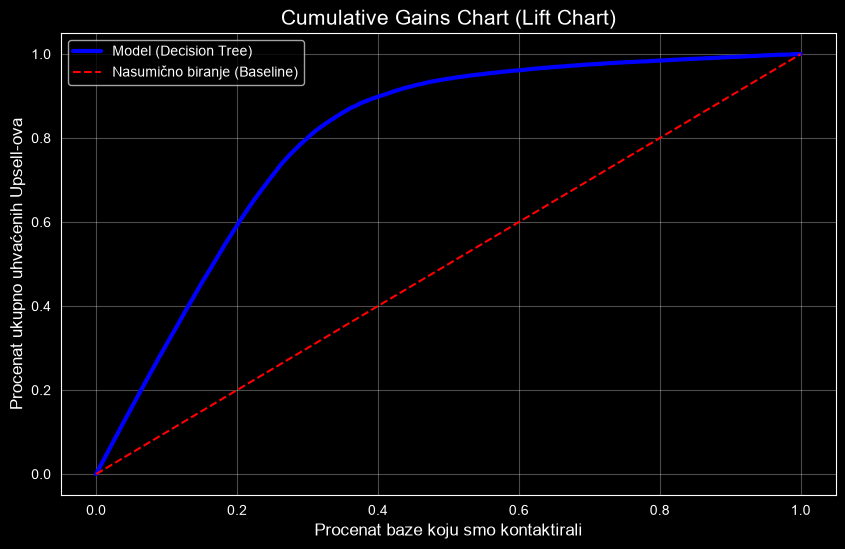

In [18]:
import matplotlib.pyplot as plt
import numpy as np

y_score = rf.predict_proba(X_test)[:, 1]

indices = np.argsort(y_score)[::-1]
y_test_sorted = y_test.values[indices]

cumulative_gains = np.cumsum(y_test_sorted) / np.sum(y_test_sorted)
percentage_of_population = np.arange(1, len(y_test_sorted) + 1) / len(y_test_sorted)

plt.figure(figsize=(10, 6))
plt.plot(percentage_of_population, cumulative_gains, label='Model (Decision Tree)', color='blue', lw=3)
plt.plot([0, 1], [0, 1], 'k--', label='Nasumično biranje (Baseline)',color='red')

plt.title('Cumulative Gains Chart (Lift Chart)', fontsize=15)
plt.xlabel('Procenat baze koju smo kontaktirali', fontsize=12)
plt.ylabel('Procenat ukupno uhvaćenih Upsell-ova', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()